<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_lab_12_LZW%2C_RLE%2C_Bit_Planes%2C_Shannon_Fano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab - 12**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter

PART 1 — LZW Coding

In [2]:
img = cv2.imread('image.jpg',0)
data = img.flatten().tolist()

In [3]:
def lzw_encode(data):
    dictionary = {chr(i): i for i in range(256)}
    dict_size = 256

    w = ""
    result = []

    for k in data:
        wk = w + chr(k)
        if wk in dictionary:
            w = wk
        else:
            result.append(dictionary[w])
            dictionary[wk] = dict_size
            dict_size += 1
            w = chr(k)

    if w:
        result.append(dictionary[w])

    return result, dictionary

encoded, final_dict = lzw_encode(data)

print("Encoded Output:", encoded[:50])

Encoded Output: [170, 256, 257, 258, 171, 171, 172, 173, 263, 174, 174, 175, 176, 177, 178, 179, 179, 181, 182, 183, 184, 185, 187, 188, 188, 191, 192, 193, 194, 196, 198, 199, 200, 288, 201, 203, 204, 205, 206, 207, 210, 211, 212, 213, 214, 215, 216, 217, 219, 220]


In [4]:
print("Initial Dictionary Size:", 256)
print("Final Dictionary Size:", len(final_dict))

original_bits = len(data) * 8
compressed_bits = len(encoded) * 12   # approx

CR = original_bits / compressed_bits

print("Compression Ratio:", CR)

Initial Dictionary Size: 256
Final Dictionary Size: 178702
Compression Ratio: 1.291180761421225


PART 2 — Run Length Coding (RLE)

In [5]:
def rle_encode(data):
    result = []
    count = 1

    for i in range(1,len(data)):
        if data[i]==data[i-1]:
            count +=1
        else:
            result.append((data[i-1],count))
            count = 1
    result.append((data[-1],count))
    return result

In [6]:
# Binary image
_, binary = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

rle_gray = rle_encode(data)
rle_bin = rle_encode(binary.flatten())

print("RLE Gray Length:", len(rle_gray))
print("RLE Binary Length:", len(rle_bin))

RLE Gray Length: 321067
RLE Binary Length: 42728


PART 3 — Bit Plane Slicing

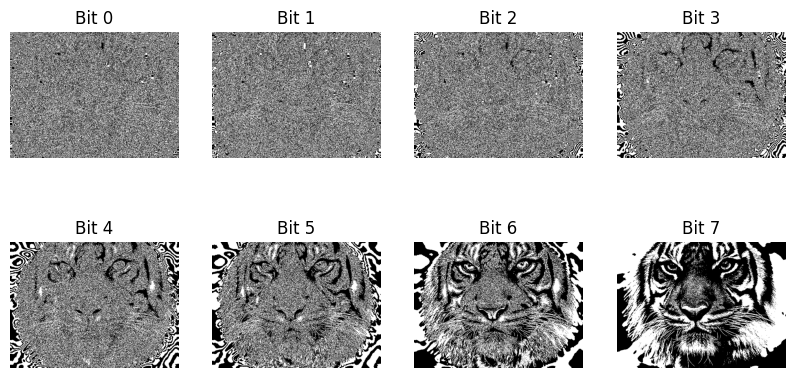

In [7]:
planes = []

for i in range(8):
    plane = (img >> i) & 1
    planes.append(plane)

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(planes[i], cmap='gray')
    plt.title(f'Bit {i}')
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(678.5), np.float64(508.5), np.float64(-0.5))

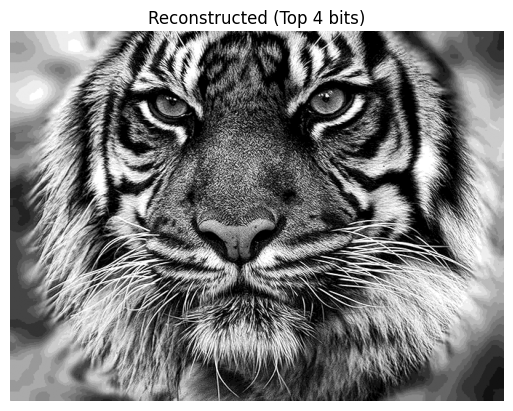

In [8]:
recon = np.zeros_like(img)

for i in range(4,8):
    recon += planes[i] * (2**i)

plt.imshow(recon, cmap='gray')
plt.title("Reconstructed (Top 4 bits)")
plt.axis('off')

In [9]:
mse = np.mean((img - recon)**2)
psnr = 10 * np.log10((255**2)/mse)

print("MSE:", mse)
print("PSNR:", psnr)

MSE: 76.5393288986751
PSNR: 29.291957108822253


PART 4 — Shannon-Fano Coding

In [10]:
data = img.flatten()
freq = Counter(data)
total = sum(freq.values())

prob = {k: v/total for k,v in freq.items()}

# sort symbols
symbols = sorted(prob.items(), key=lambda x: x[1], reverse=True)

codes = {}

def shannon_fano(symbols, prefix=""):
    if len(symbols) == 1:
        codes[symbols[0][0]] = prefix
        return

    total = sum([p for _,p in symbols])
    acc = 0

    for i in range(len(symbols)):
        acc += symbols[i][1]
        if acc >= total/2:
            break

    shannon_fano(symbols[:i+1], prefix+"0")
    shannon_fano(symbols[i+1:], prefix+"1")

shannon_fano(symbols)

print("Probability Table:")
print(list(prob.items())[:10])

print("\nCodes:")
print(list(codes.items())[:10])

encoded = ''.join([codes[x] for x in data[:100]])

print("\nEncoded Output (sample):", encoded)

Probability Table:
[(np.uint8(170), 0.0040276495829125805), (np.uint8(171), 0.004131812934194803), (np.uint8(172), 0.004099985243525235), (np.uint8(173), 0.004218615726929988), (np.uint8(174), 0.003992928465818507), (np.uint8(175), 0.004131812934194803), (np.uint8(176), 0.0041404932134683214), (np.uint8(177), 0.004189681462684926), (np.uint8(178), 0.004062370700006655), (np.uint8(179), 0.004192574889109432)]

Codes:
[(np.uint8(0), '000000'), (np.uint8(255), '0000010'), (np.uint8(3), '0000011'), (np.uint8(5), '00001000'), (np.uint8(4), '00001001'), (np.uint8(6), '0000101'), (np.uint8(2), '0000110'), (np.uint8(7), '0000111'), (np.uint8(8), '00010000'), (np.uint8(9), '00010001')]

Encoded Output (sample): 100000011000000110000001100000011000000110000001100000011000000110000001100000010110010101100101011011101010100010101000101010010001100100011000110011001100100010110000111100001010110010101100101111011000100101101010000111101011001001001101110101011101011001000001011100100010110111000001

Conclusion : LZW and Shannon-Fano are lossless techniques, while bit-plane slicing allows controlled lossy reconstruction.